# Prueba de calculo de Rates

Para esta prueba voy a usar los datos que recolecté usando plot digitalizer por lo tanto pueden ser erroneos o tener leves diferencias con los reales.

Por otro lado usamos la aproximación:

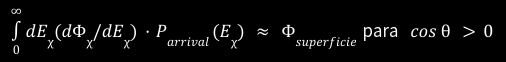

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import interp1d
from scipy.integrate import simpson


custom_params = {
    'font.family': 'serif',
}

plt.rcParams.update(custom_params)

## Datos de flujos 

In [3]:
df_pb = pd.read_csv('Flujo_PB.csv',sep = ';')
df_md = pd.read_csv('Flujo_MD_tot.csv',sep = ';')
masa_pb = df_pb[df_pb.columns[0]]
flujo_pb = df_pb[df_pb.columns[1]]
masa_md = df_md[df_md.columns[0]]
flujo_md = df_md[df_md.columns[1]]


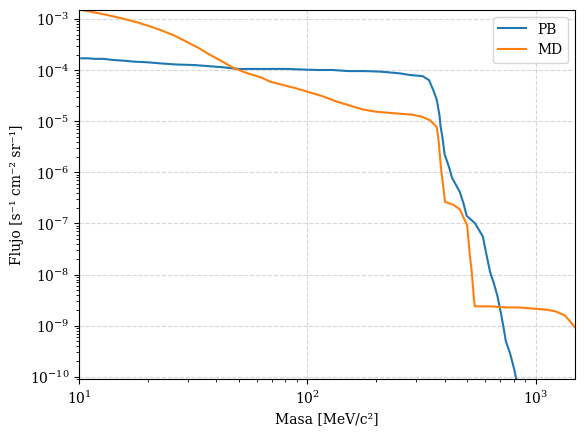

In [ ]:
plt.plot(masa_pb, flujo_pb, '-', label='PB')
plt.plot(masa_md, flujo_md, '-', label='MD')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e1,np.max(masa_md))
plt.ylim(np.min(flujo_pb),4e-8)
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻² sr⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()


Asumo que el flujo en superficie es isotrópico y por lo tanto no depende del ángulo theta para theta menor a $\pi/2$ y solo hay que multiplicar por $2\pi$ para integrar en la semiesfera que estamos considerando.

In [5]:
masa_pb_ = df_pb[df_pb.columns[0]]
flujo_pb_ =2*np.pi*df_pb[df_pb.columns[1]] 
masa_md_ = df_md[df_md.columns[0]]
flujo_md_ =2*np.pi*df_md[df_md.columns[1]]
orden = np.argsort(masa_pb_)
orden_md = np.argsort(masa_md_)
masa_pb_ = masa_pb_[orden]
flujo_pb_ = flujo_pb_[orden]
masa_md_ = masa_md_[orden_md]
flujo_md_ = flujo_md_[orden_md] 


In [6]:
masa_md = np.logspace(np.log10(np.min(masa_md)),np.log10(np.max(masa_md)),100)
masa_pb = np.logspace(np.log10(np.min(masa_pb)),np.log10(np.max(masa_pb)),100)
flujo_pb_interpolado = interp1d(masa_pb_, flujo_pb_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_md_interpolado = interp1d(masa_md_, flujo_md_, kind='linear', bounds_error=False, fill_value=0.0)
flujo_pb = flujo_pb_interpolado(masa_pb)
flujo_md = flujo_md_interpolado(masa_md)

In [7]:
flujo_pb_df = pd.DataFrame({
    'Masa[MeV/c2]': masa_pb,
    'Flujo[s-1cm-2]': flujo_pb
}
)
flujo_md_df = pd.DataFrame({
    'Masa[MeV/c2]': masa_md,
    'Flujo[s-1cm-2]': flujo_md
}
)
flujo_pb_df.to_csv('Flujo_PB_interpolado.csv', index=False)
flujo_md_df.to_csv('Flujo_MD_interpolado.csv', index=False)

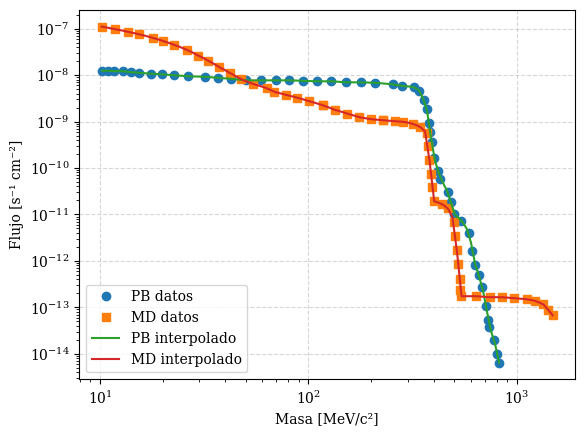

In [8]:
plt.plot(masa_pb_,flujo_pb_, 'o', label='PB datos')
plt.plot(masa_md_,flujo_md_, 's', label='MD datos')
plt.plot(masa_pb, flujo_pb, '-', label='PB interpolado')
plt.plot(masa_md, flujo_md, '-', label='MD interpolado')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Flujo [s⁻¹ cm⁻²]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Datos sección eficaz

In [9]:
df_se = pd.read_csv('Seccion_eficaz_DEr_mCP.csv',sep = ';')

In [10]:
Er = np.array(df_se[df_se.columns[0]])
sigma_er = np.array(df_se[df_se.columns[1]])
orden = np.argsort(Er)
Er = Er[orden]
sigma_er = sigma_er[orden]

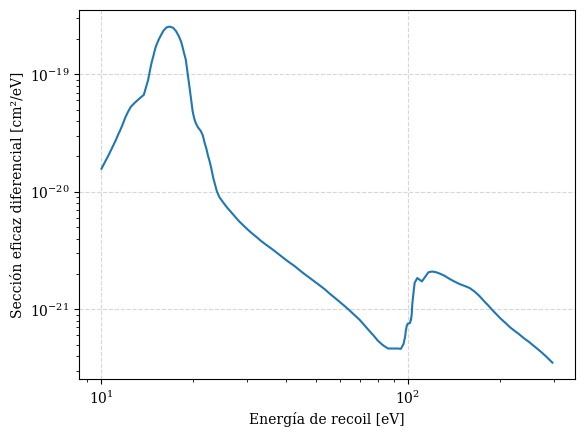

In [11]:
plt.plot(Er, sigma_er, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)

Tengo que pasar esta sección eficaz para el caso de que tengamos $\varepsilon = 10^{-2}$

In [12]:
sigma_er = np.array((df_se[df_se.columns[1]]/(1e-6)**2)*(1e-2)**2)

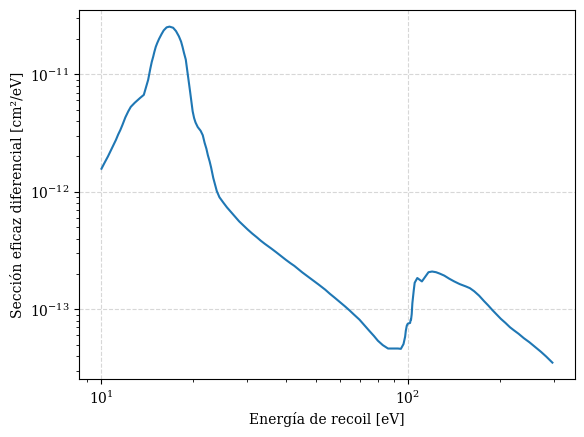

In [13]:
plt.plot(Er, sigma_er, '-', label='Sección eficaz')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energía de recoil [eV]')
plt.ylabel('Sección eficaz diferencial [cm²/eV]')
plt.grid(linestyle='--', alpha=0.5)

In [14]:
len(masa_pb),len(masa_md),len(sigma_er),len(Er)

(100, 100, 145, 145)

In [15]:
espectros_pb = np.zeros((len(masa_pb),len(Er)))
espectros_md = np.zeros((len(masa_md),len(Er)))
for i in range(len(masa_pb)):
    espectros_pb[i,:] = flujo_pb[i]*sigma_er

for i in range(len(masa_md)):
    espectros_md[i,:] = flujo_md[i]*sigma_er

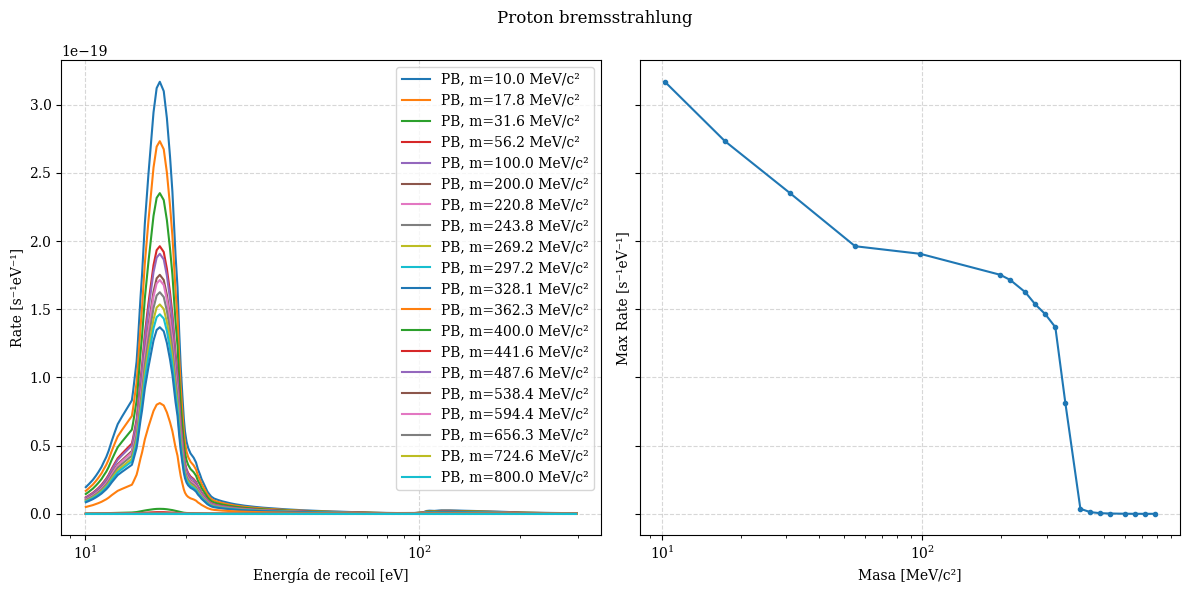

In [16]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(8e2),15)
masa = np.concatenate((masa1,masa2))
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(espectros_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('Rate [s⁻¹eV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [s⁻¹eV⁻¹]')
fig.suptitle('Proton bremsstrahlung')
plt.tight_layout()

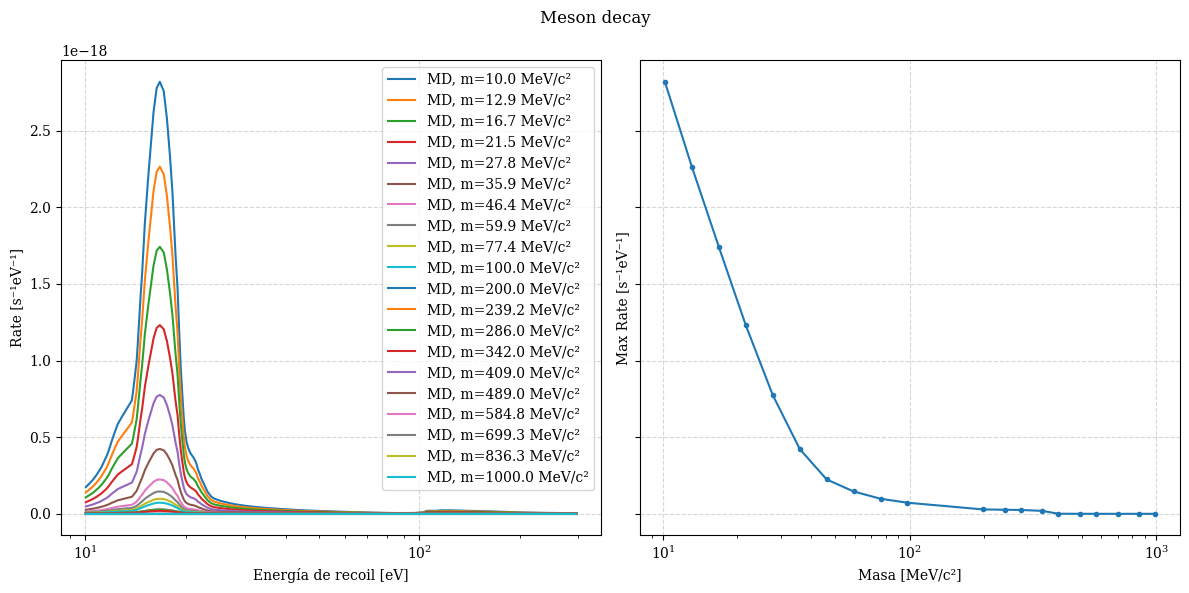

In [17]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)
masa1 = np.logspace(1,2,10)
masa2 = np.logspace(np.log10(2e2),np.log10(1e3),10)
masa = np.concatenate((masa1,masa2))
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, espectros_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(espectros_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel('Rate [s⁻¹eV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [s⁻¹eV⁻¹]')
fig.suptitle('Meson decay')
plt.tight_layout()

In [18]:
mass_md

array([ 10.18939953,  13.10492615,  16.85468204,  21.677368  ,
        27.87998506,  35.85737748,  46.11736758,  59.31308262,
        76.28453128,  98.11207673, 198.48296102, 242.7459648 ,
       282.30827679, 345.26487648, 401.53554107, 491.08060368,
       571.11605999, 698.47869198, 854.24402732, 993.46722206])

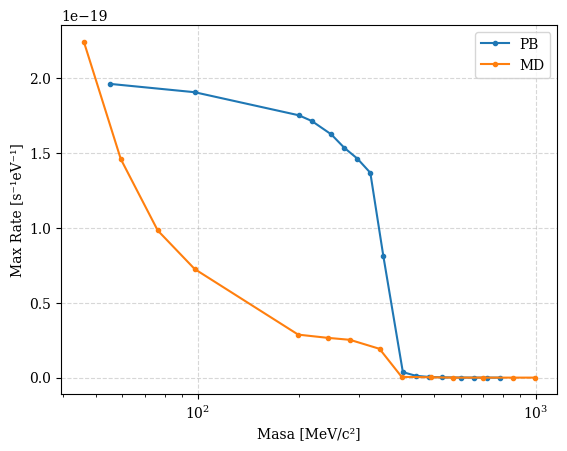

In [19]:
plt.plot(mass_pb[mass_pb>40], max_pb[mass_pb>40], '.-')
plt.plot(mass_md[mass_md>40], max_md[mass_md>40], '.-')
plt.xscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel('Max Rate [s⁻¹eV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend(['PB','MD'])
plt.show()


Tenemos que poner el rate diferencial en unidades de DRU

$$
[DRU]= kg^{-1}day^{-1}keV^{-1}
$$

In [20]:
rho_g = 6.02214076e23/28.0855 # [1/g]
f_conversion = 8.64e10 # [1/(kg day keV)] ---> [1/(g s eV)]
rate_dif_pb = espectros_pb*rho_g*(f_conversion)
rate_dif_md = espectros_md*rho_g*(f_conversion)


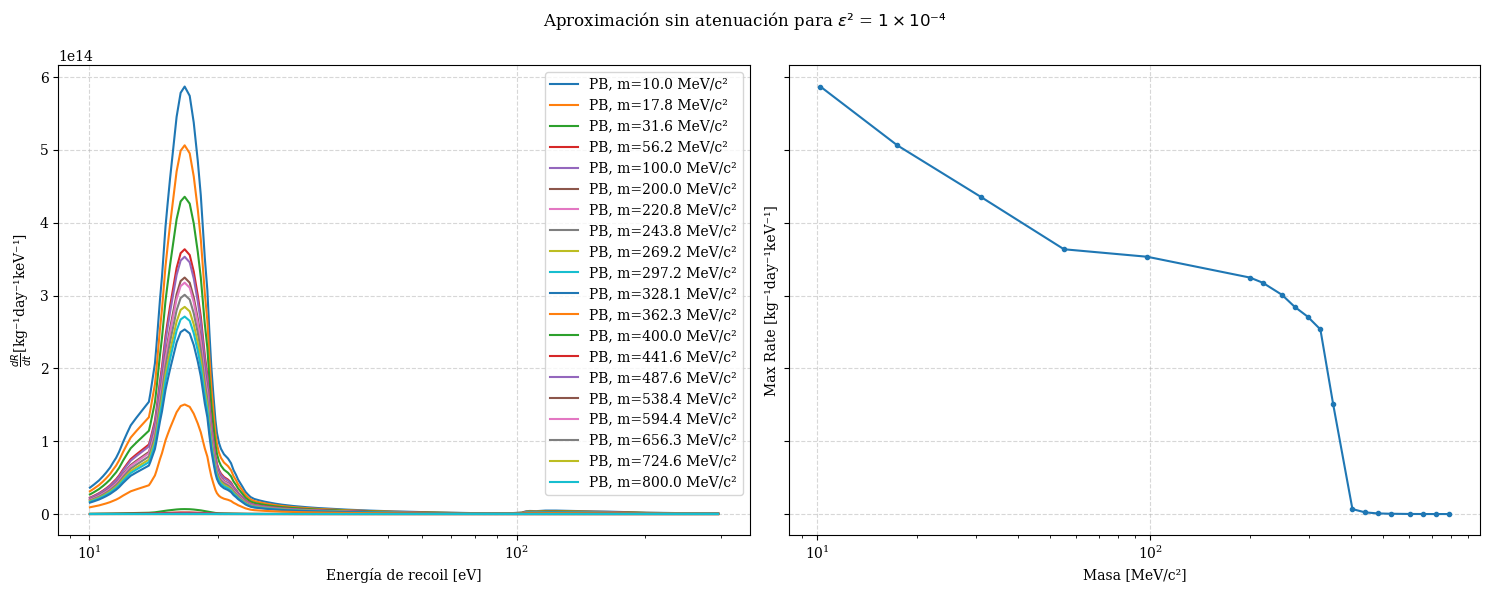

In [21]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(15,6), sharey=True)
masa1 = np.logspace(1,2,5)
masa2 = np.logspace(np.log10(2e2),np.log10(8e2),15)
masa = np.concatenate((masa1,masa2))
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(rate_dif_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')
plt.tight_layout()

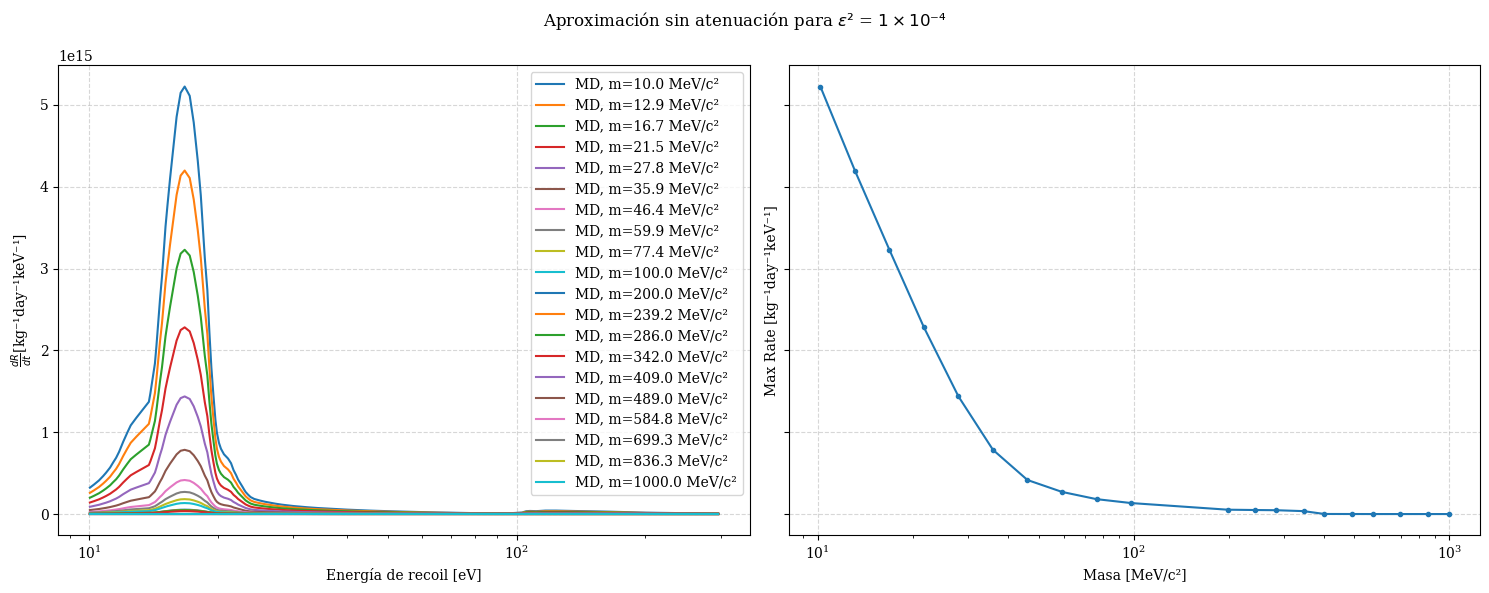

In [22]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(15,6), sharey=True)
masa1 = np.logspace(1,2,10)
masa2 = np.logspace(np.log10(2e2),np.log10(1e3),10)
masa = np.concatenate((masa1,masa2))
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(rate_dif_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')
plt.tight_layout()


Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

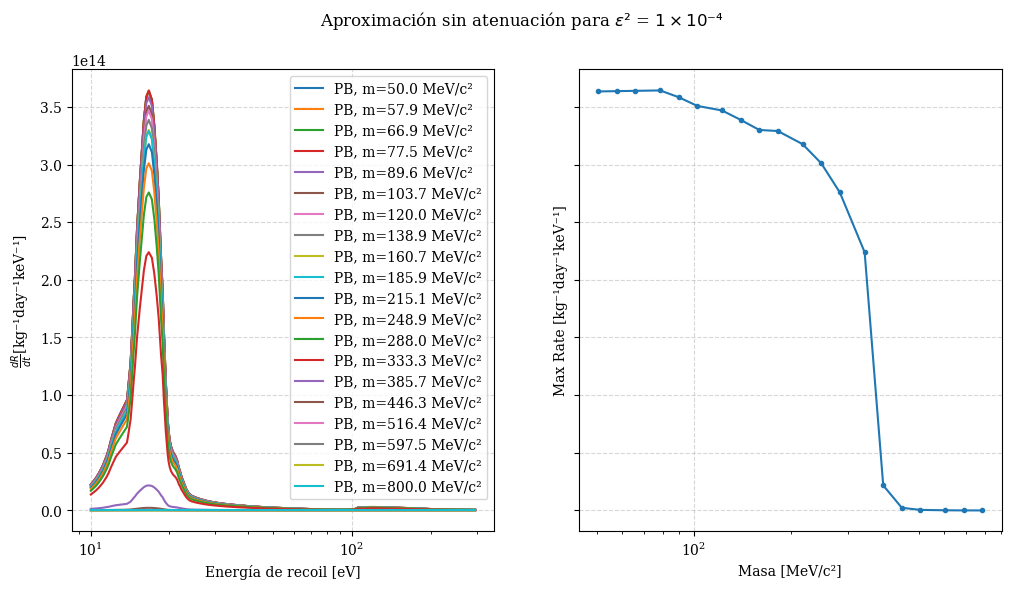

In [23]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)

masa = np.logspace(np.log10(50),np.log10(8e2),20)
mass_pb = []
max_pb = []
for i in range(len(masa)):
    dif  = np.abs(masa_pb-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_pb[idx,:], '-', label=f'PB, m={masa[i]:.1f} MeV/c²')
    mass_pb.append(masa_pb[idx])
    max_pb.append(np.max(rate_dif_pb[idx,:]))
    
mass_pb,max_pb = np.array(mass_pb),np.array(max_pb)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_pb, max_pb, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

Text(0.5, 0.98, 'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

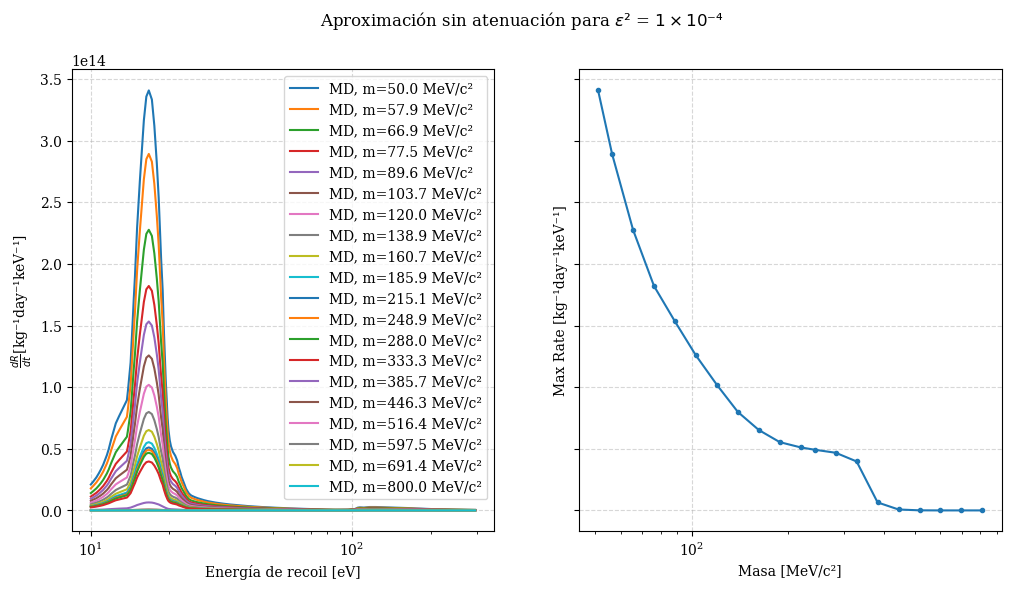

In [24]:
plt.close('all')
fig, ax = plt.subplots(1,2, figsize=(12,6), sharey=True)

masa = np.logspace(np.log10(50),np.log10(8e2),20)
mass_md = []
max_md = []
for i in range(len(masa)):
    dif  = np.abs(masa_md-masa[i])
    
    idx = np.argmin(dif)

    ax[0].plot(Er, rate_dif_md[idx,:], '-', label=f'MD, m={masa[i]:.1f} MeV/c²')
    mass_md.append(masa_md[idx])
    max_md.append(np.max(rate_dif_md[idx,:]))
    
mass_md,max_md = np.array(mass_md),np.array(max_md)
ax[0].set_xlabel('Energía de recoil [eV]')
ax[0].set_ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
ax[0].set_xscale('log')
ax[0].grid(linestyle='--', alpha=0.5)
ax[0].legend()
ax[1].plot(mass_md, max_md, '.-')
ax[1].set_xlabel('Masa [MeV/c²]')
ax[1].set_xscale('log')
ax[1].grid(linestyle='--', alpha=0.5)
ax[1].set_ylabel('Max Rate [kg⁻¹day⁻¹keV⁻¹]')
fig.suptitle(f'Aproximación sin atenuación para $\\varepsilon²$ = $1\\times 10⁻⁴$')

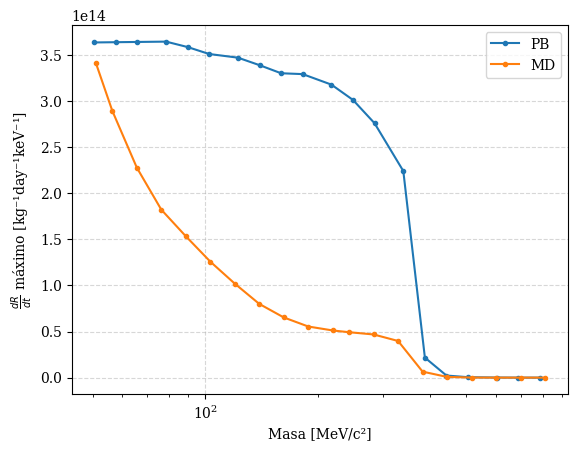

In [25]:
plt.plot(mass_pb, max_pb, '.-')
plt.plot(mass_md, max_md, '.-')
plt.xscale('log')
plt.xlabel('Masa [MeV/c²]')
plt.ylabel(f'$ \\frac{{dR}}{{dt}}$ máximo [kg⁻¹day⁻¹keV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend(['PB','MD'])
plt.show()


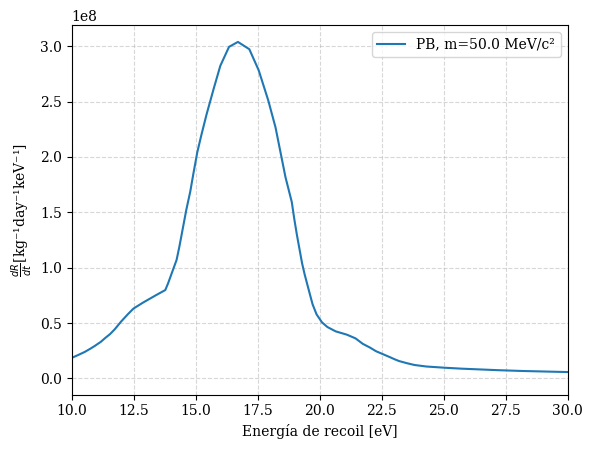

In [26]:
plt.plot(Er, rate_dif_pb[-1,:], '-', label=f'PB, m={masa[0]:.1f} MeV/c²')
plt.xlim(10,30)
plt.xlabel('Energía de recoil [eV]')
plt.ylabel(f'$ \\frac{{dR}}{{dt}} $[kg⁻¹day⁻¹keV⁻¹]')
plt.grid(linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [27]:
rate_dif_md.shape

(100, 145)

## **Integrales**

Tenemos que hacer la integral de:

$$
\int_{E_{min}}^{E_{max}} \frac{dR}{dE_r}(E_r)\cdot P_{PC}(E_r) dE_r
$$

Pero como ambos datos no tienen el mismo tamaño hay que hacer una interpolación para que ambos tengan el mismo tamaño.


In [28]:
rate_dif_pb.shape

(100, 145)

In [29]:
path = '/home/lurishi/Escritorio/Doctorado/Data_Er_a_e'
df_PC_1 = pd.read_csv(path+'/1e-.csv',sep = ';')
df_PC_2 = pd.read_csv(path+'/2e-.csv',sep = ';')
df_PC_3 = pd.read_csv(path+'/3e-.csv',sep = ';')
df_PC_4 = pd.read_csv(path+'/4e-.csv',sep = ';')
df_PC_5 = pd.read_csv(path+'/5e-.csv',sep = ';')
df_PC_6 = pd.read_csv(path+'/6e-.csv',sep = ';')
df_PC_7 = pd.read_csv(path+'/7e-.csv',sep = ';')

Er_pc1, Er_pc2, Er_pc3, Er_pc4, Er_pc5, Er_pc6, Er_pc7 = df_PC_1[df_PC_1.columns[0]]/1000, df_PC_2[df_PC_2.columns[0]]/1000, df_PC_3[df_PC_3.columns[0]]/1000, df_PC_4[df_PC_4.columns[0]]/1000, df_PC_5[df_PC_5.columns[0]]/1000, df_PC_6[df_PC_6.columns[0]]/1000, df_PC_7[df_PC_7.columns[0]]/1000
P_PC_1,P_PC_2, P_PC_3, P_PC_4, P_PC_5, P_PC_6, P_PC_7 = df_PC_1[df_PC_1.columns[1]], df_PC_2[df_PC_2.columns[1]], df_PC_3[df_PC_3.columns[1]], df_PC_4[df_PC_4.columns[1]], df_PC_5[df_PC_5.columns[1]], df_PC_6[df_PC_6.columns[1]], df_PC_7[df_PC_7.columns[1]]

Er_lista = [Er_pc1, Er_pc2, Er_pc3, Er_pc4, Er_pc5, Er_pc6, Er_pc7]
P_PC_lista = [P_PC_1, P_PC_2, P_PC_3, P_PC_4, P_PC_5, P_PC_6, P_PC_7]

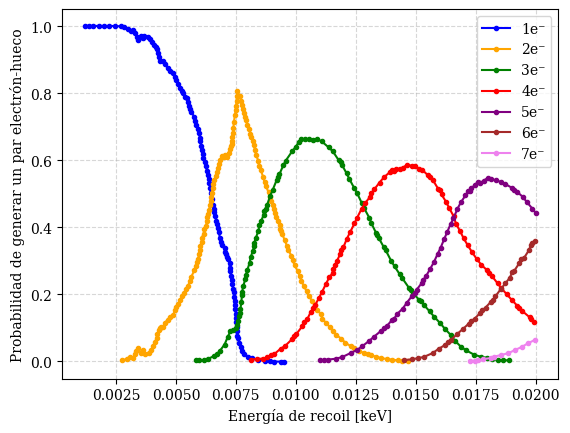

In [ ]:
plt.plot(Er_pc1, P_PC_1, '.-',label = '1e⁻',color = 'blue')
plt.plot(Er_pc2, P_PC_2, '.-',label = '2e⁻',color = 'orange')
plt.plot(Er_pc3, P_PC_3, '.-',label = '3e⁻',color = 'green')
plt.plot(Er_pc4, P_PC_4, '.-',label = '4e⁻',color = 'red')
plt.plot(Er_pc5, P_PC_5, '.-',label = '5e⁻',color = 'purple')
plt.plot(Er_pc6, P_PC_6, '.-',label = '6e⁻',color = 'brown')
plt.plot(Er_pc7, P_PC_7, '.-',label = '7e⁻',color = 'violet')
plt.grid(linestyle='--', alpha=0.5)
plt.xlabel('Energía de recoil [keV]')
plt.ylabel('Probabilidad de generar un par electrón-hueco')
plt.legend()

In [31]:
Er_pb_md = Er
rate_integrado_pb = pd.DataFrame(columns = ['masa[MeV/c2]', '1e','2e','3e','4e','5e','6e','7e'])
rate_integrado_md = pd.DataFrame(columns = ['masa[MeV/c2]', '1e','2e','3e','4e','5e','6e','7e'])
for i in range(len(masa_pb)):

    rate_pb = np.asarray(rate_dif_pb[i, :], dtype=float)
    rate_md = np.asarray(rate_dif_md[i, :], dtype=float)
    
    fila_pb = []
    fila_md = []
    for j in range(len(Er_lista)):
        Er_pc = Er_lista[j]
        P_PC = P_PC_lista[j]
        Er_pb_md = np.asarray(Er, dtype=float) / 1000.0  # keV
        Er_pc = np.asarray(Er_pc, dtype=float)
        E_min = max(Er_pb_md.min(), Er_pc.min())
        E_max = min(Er_pb_md.max(), Er_pc.max())
        print(f'E_min: {E_min}, E_max: {E_max}')
        if E_min >= E_max:
            integral_pb = 0.0
            integral_md = 0.0
            fila_pb.append(integral_pb)
            fila_md.append(integral_md)
            
        else:
            E_common = np.linspace(E_min, E_max, 1000)
            f_prob_pc = interp1d(Er_pc, P_PC, kind='linear', bounds_error=False, fill_value=np.nan)
            f_rate_pb = interp1d(Er_pb_md, rate_pb, kind='linear', bounds_error=False, fill_value=np.nan)
            f_rate_md = interp1d(Er_pb_md, rate_md, kind='linear', bounds_error=False, fill_value=np.nan)
            
            integrand_pb = f_prob_pc(E_common) * f_rate_pb(E_common)
            integrand_md = f_prob_pc(E_common) * f_rate_md(E_common)
            
            integral_pb = simpson(integrand_pb, E_common)
            integral_md = simpson(integrand_md, E_common)
            
            fila_pb.append(integral_pb)
            fila_md.append(integral_md)
    rate_integrado_pb.loc[len(rate_integrado_pb)] = [masa_pb[i]] + fila_pb
    rate_integrado_md.loc[len(rate_integrado_md)] = [masa_md[i]] + fila_md



E_min: 0.010027190024098449, E_max: 0.00952229
E_min: 0.010027190024098449, E_max: 0.0146797
E_min: 0.010027190024098449, E_max: 0.018875299999999998
E_min: 0.010027190024098449, E_max: 0.0199214
E_min: 0.0110114, E_max: 0.0199952
E_min: 0.0145065, E_max: 0.0199645
E_min: 0.017275500000000003, E_max: 0.0199829
E_min: 0.010027190024098449, E_max: 0.00952229
E_min: 0.010027190024098449, E_max: 0.0146797
E_min: 0.010027190024098449, E_max: 0.018875299999999998
E_min: 0.010027190024098449, E_max: 0.0199214
E_min: 0.0110114, E_max: 0.0199952
E_min: 0.0145065, E_max: 0.0199645
E_min: 0.017275500000000003, E_max: 0.0199829
E_min: 0.010027190024098449, E_max: 0.00952229
E_min: 0.010027190024098449, E_max: 0.0146797
E_min: 0.010027190024098449, E_max: 0.018875299999999998
E_min: 0.010027190024098449, E_max: 0.0199214
E_min: 0.0110114, E_max: 0.0199952
E_min: 0.0145065, E_max: 0.0199645
E_min: 0.017275500000000003, E_max: 0.0199829
E_min: 0.010027190024098449, E_max: 0.00952229
E_min: 0.01002719

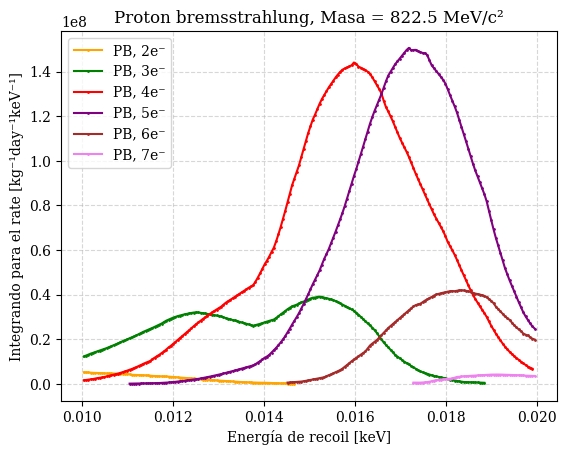

In [32]:
E_min = 0.01
E_max = 0.02
E_common = np.linspace(E_min, E_max, 200)
f_prob_pc_2 = interp1d(Er_pc2, P_PC_2, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_3 = interp1d(Er_pc3, P_PC_3, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_4 = interp1d(Er_pc4, P_PC_4, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_5 = interp1d(Er_pc5, P_PC_5, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_6 = interp1d(Er_pc6, P_PC_6, kind='linear', bounds_error=False, fill_value=np.nan)
f_prob_pc_7 = interp1d(Er_pc7, P_PC_7, kind='linear', bounds_error=False, fill_value=np.nan)
f_rate_pb = interp1d(Er_pb_md, rate_pb, kind='linear', bounds_error=False, fill_value=np.nan)
f_rate_md = interp1d(Er_pb_md, rate_md, kind='linear', bounds_error=False, fill_value=np.nan)

integrand_pb_2 = f_prob_pc_2(E_common) * f_rate_pb(E_common)
integrand_md_2 = f_prob_pc_2(E_common) * f_rate_md(E_common)
integrand_pb_3 = f_prob_pc_3(E_common) * f_rate_pb(E_common)
integrand_md_3 = f_prob_pc_3(E_common) * f_rate_md(E_common)
integrand_pb_4 = f_prob_pc_4(E_common) * f_rate_pb(E_common)
integrand_md_4 = f_prob_pc_4(E_common) * f_rate_md(E_common)
integrand_pb_5 = f_prob_pc_5(E_common) * f_rate_pb(E_common)
integrand_md_5 = f_prob_pc_5(E_common) * f_rate_md(E_common)
integrand_pb_6 = f_prob_pc_6(E_common) * f_rate_pb(E_common)
integrand_md_6 = f_prob_pc_6(E_common) * f_rate_md(E_common)
integrand_pb_7 = f_prob_pc_7(E_common) * f_rate_pb(E_common)
integrand_md_7 = f_prob_pc_7(E_common) * f_rate_md(E_common)

plt.plot(E_common, integrand_pb_2,'-', marker='.',markersize=2, label='PB, 2e⁻',color = 'orange')
plt.plot(E_common, integrand_pb_3, '-', marker='.', markersize=2, label='PB, 3e⁻',color = 'green')
plt.plot(E_common, integrand_pb_4, '-', marker='.', markersize=2, label='PB, 4e⁻',color = 'red')
plt.plot(E_common, integrand_pb_5, '-', marker='.', markersize=2, label='PB, 5e⁻',color = 'purple')
plt.plot(E_common, integrand_pb_6, '-', marker='.', markersize=2, label='PB, 6e⁻',color = 'brown')
plt.plot(E_common, integrand_pb_7, '-', marker='.', markersize=2, label='PB, 7e⁻',color = 'violet')
plt.grid(linestyle='--', alpha=0.5)
plt.xlabel('Energía de recoil [keV]')
plt.ylabel('Integrando para el rate [kg⁻¹day⁻¹keV⁻¹]')
plt.title(f'Proton bremsstrahlung, Masa = {masa_pb[-1]:.1f} MeV/c²')
plt.legend()

In [33]:
eff2 = 0.51*0.96*0.94
eff3 = 0.64*0.96*0.93
eff4 = 0.71*0.96*0.92
eff5 = 0.75*0.95*0.91
eff6 = 0.78*0.95*0.90
eff7 = 0.80*0.95*0.89
rates_pb_final = rate_integrado_pb.copy()
rates_md_final = rate_integrado_md.copy()
rates_pb_final[rates_pb_final.columns[2]] = rate_integrado_pb[rates_pb_final.columns[2]]*eff2
rates_pb_final[rates_pb_final.columns[3]] = rate_integrado_pb[rates_pb_final.columns[3]]*eff3
rates_pb_final[rates_pb_final.columns[4]] = rate_integrado_pb[rates_pb_final.columns[4]]*eff4
rates_pb_final[rates_pb_final.columns[5]] = rate_integrado_pb[rates_pb_final.columns[5]]*eff5
rates_pb_final[rates_pb_final.columns[6]] = rate_integrado_pb[rates_pb_final.columns[6]]*eff6
rates_pb_final[rates_pb_final.columns[7]] = rate_integrado_pb[rates_pb_final.columns[7]]*eff7
rates_md_final[rates_md_final.columns[2]] = rate_integrado_md[rates_md_final.columns[2]]*eff2
rates_md_final[rates_md_final.columns[3]] = rate_integrado_md[rates_md_final.columns[3]]*eff3
rates_md_final[rates_md_final.columns[4]] = rate_integrado_md[rates_md_final.columns[4]]*eff4
rates_md_final[rates_md_final.columns[5]] = rate_integrado_md[rates_md_final.columns[5]]*eff5
rates_md_final[rates_md_final.columns[6]] = rate_integrado_md[rates_md_final.columns[6]]*eff6
rates_md_final[rates_md_final.columns[7]] = rate_integrado_md[rates_md_final.columns[7]]*eff7


In [34]:
rates_pb_final.to_csv('Rates_PB_eps_1e-2_m10-800.csv', index=False)
rates_md_final.to_csv('Rates_MD_eps_1e-2_m10-800.csv', index=False)

In [35]:
rates_md_final.head(5)

,masa[MeV/c2],1e,2e,3e,4e,5e,6e,7e
0,10.189400,0.0,9.237267e+10,1.941651e+12,6.156884e+12,5.756677e+12,1.483756e+12,9.394587e+10
1,10.715336,0.0,8.880509e+10,1.866662e+12,5.919095e+12,5.534345e+12,1.426451e+12,9.031752e+10
2,11.268419,0.0,8.505336e+10,1.787801e+12,5.669032e+12,5.300537e+12,1.366188e+12,8.650190e+10
3,11.850050,0.0,8.114052e+10,1.705554e+12,5.408231e+12,5.056688e+12,1.303337e+12,8.252242e+10
4,12.461703,0.0,7.776736e+10,1.634651e+12,5.183401e+12,4.846473e+12,1.249155e+12,7.909182e+10


In [36]:
df = pd.read_csv('/home/lurishi/Descargas/dm.dat',sep = '\t')

In [37]:
df

,FDM1: mX [MeV] Rate [1/(g-day)],ne1,ne2,ne3,ne4,ne5,ne6,ne7,ne8,ne9,ne10
0,0.200,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.250,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.275,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
114,100.000,0.165088,0.115769,0.068201,0.025980,0.010519,0.005638,0.003192,0.001669,0.000826,0.000377
115,200.000,0.084056,0.059877,0.035959,0.014032,0.005837,0.003204,0.001857,0.000997,0.000509,0.000240
116,500.000,0.034093,0.024501,0.014876,0.005883,0.002482,0.001380,0.000810,0.000442,0.000230,0.000110
117,1000.000,0.017150,0.012349,0.007512,0.002985,0.001266,0.000706,0.000417,0.000229,0.000119,0.000058
